<a href="https://colab.research.google.com/github/gabrieljsrodrigues/proj2-CompVisual/blob/main/ProjetoCompVis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python

In [ ]:
from google.colab import files

uploaded = files.upload()
caminho = list(uploaded.keys())[0]

print(caminho)

Saving raiox.jpeg to raiox.jpeg
raiox.jpeg


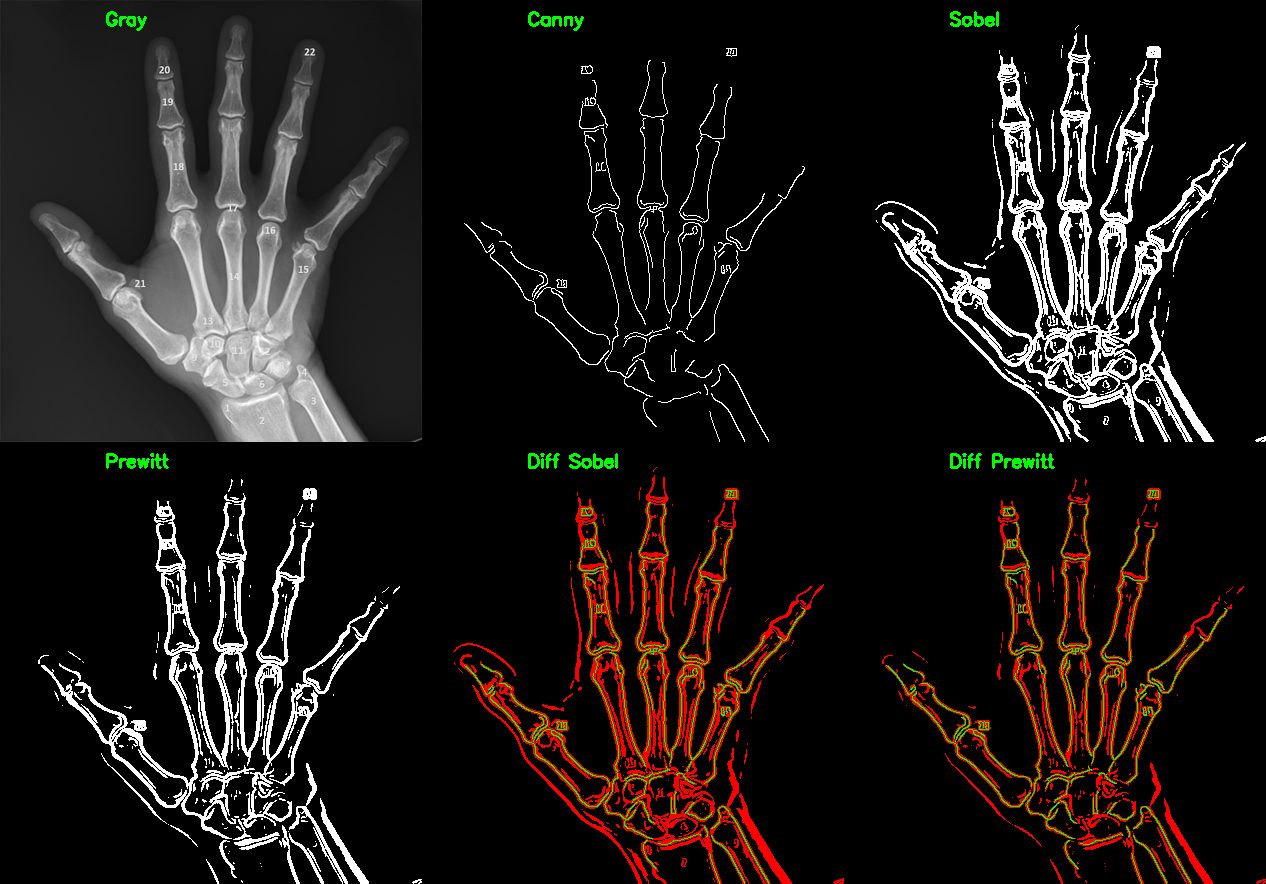

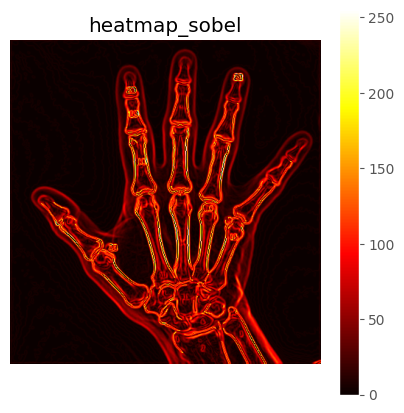

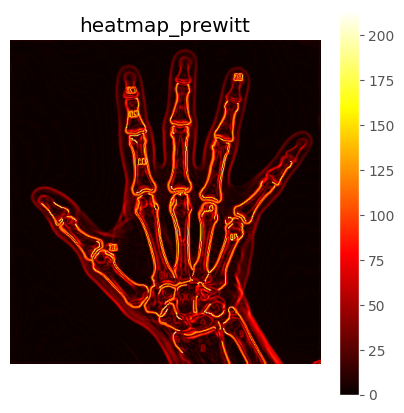

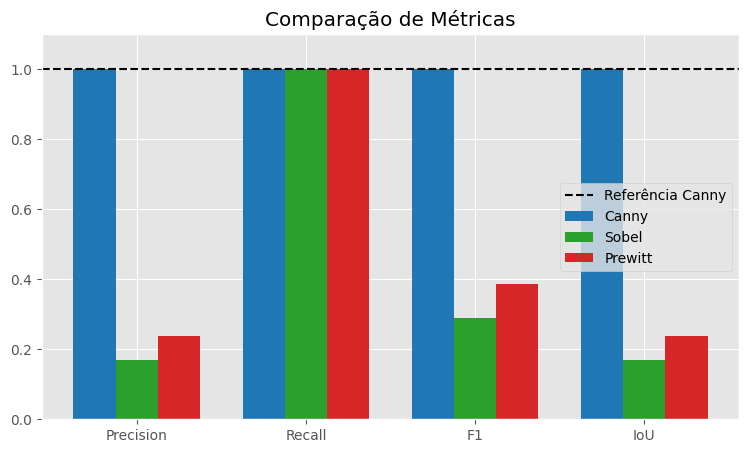

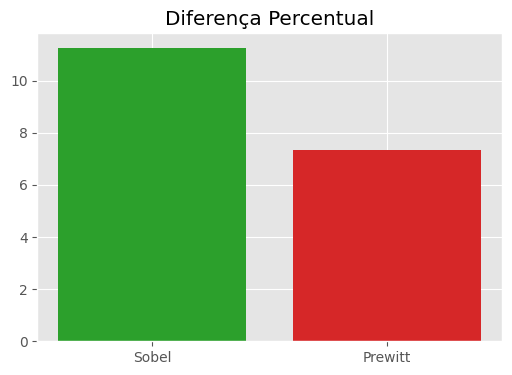


RESULTADOS (vs CANNY)

SOBEL:
Precision: 0.1696
Recall:    1.0000
F1:        0.2899
IoU:       0.1696
Dif:       11.26%

PREWITT:
Precision: 0.2387
Recall:    1.0000
F1:        0.3853
IoU:       0.2387
Dif:       7.33%

Veredito: Prewitt foi mais próximo do Canny


In [ ]:
import cv2
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

def carregar_imagem(caminho):
    img = cv2.imread(caminho)
    if img is None:
        raise Exception("Erro ao carregar imagem")
    return img

def converter_cinza(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def aplicar_blur(img):
    return cv2.GaussianBlur(img, (5, 5), 0)

def detectar_canny(img):
    return cv2.Canny(img, 100, 200)

def detectar_sobel(img):
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.sqrt(sobelx**2 + sobely**2)
    sobel_8bit = np.uint8(np.clip(sobel, 0, 255))
    _, sobel_bin = cv2.threshold(sobel_8bit, 50, 255, cv2.THRESH_BINARY)
    return sobel_bin

def detectar_prewitt(img):
    kernelx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
    kernely = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
    px = cv2.filter2D(img, cv2.CV_64F, kernelx)
    py = cv2.filter2D(img, cv2.CV_64F, kernely)
    prewitt = np.sqrt(px**2 + py**2)
    prewitt_8bit = np.uint8(np.clip(prewitt, 0, 255))
    _, prewitt_bin = cv2.threshold(prewitt_8bit, 50, 255, cv2.THRESH_BINARY)
    return prewitt_bin

def detectar_sobel_raw(img):
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.sqrt(sobelx**2 + sobely**2)
    return np.uint8(np.clip(sobel, 0, 255))

def detectar_prewitt_raw(img):
    kernelx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
    kernely = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
    px = cv2.filter2D(img, cv2.CV_64F, kernelx)
    py = cv2.filter2D(img, cv2.CV_64F, kernely)
    prewitt = np.sqrt(px**2 + py**2)
    return np.uint8(np.clip(prewitt, 0, 255))

def calcular_diferenca(base, comparacao):
    diff = cv2.absdiff(base, comparacao)
    pixels_diferentes = np.count_nonzero(diff)
    total_pixels = diff.size
    porcentagem = (pixels_diferentes / total_pixels) * 100
    return diff, pixels_diferentes, porcentagem

def calcular_metricas(base, comparacao):
    base_bin = base > 0
    comp_bin = comparacao > 0
    TP = np.logical_and(base_bin, comp_bin).sum()
    FP = np.logical_and(~base_bin, comp_bin).sum()
    FN = np.logical_and(base_bin, ~comp_bin).sum()
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
    return precision, recall, f1

def calcular_iou(base, comparacao):
    base_bin = base > 0
    comp_bin = comparacao > 0
    intersecao = np.logical_and(base_bin, comp_bin).sum()
    uniao = np.logical_or(base_bin, comp_bin).sum()
    return intersecao / uniao if uniao != 0 else 0

def heatmap(diff, nome):
    plt.figure(figsize=(5,5))
    plt.imshow(diff, cmap='hot')
    plt.colorbar()
    plt.title(nome)
    plt.axis('off')
    plt.savefig(f"output/{nome}.png")
    plt.show()

def diff_colorido(base, comparacao):
    base_bin = base > 0
    comp_bin = comparacao > 0
    h, w = base.shape
    resultado = np.zeros((h, w, 3), dtype=np.uint8)
    acerto = np.logical_and(base_bin, comp_bin)
    falso_positivo = np.logical_and(~base_bin, comp_bin)
    falso_negativo = np.logical_and(base_bin, ~comp_bin)
    resultado[acerto] = [0,255,0]
    resultado[falso_positivo] = [0,0,255]
    resultado[falso_negativo] = [255,0,0]
    return resultado

def gerar_graficos(pct_sobel, pct_prewitt,
                   prec_sobel, rec_sobel, f1_sobel, iou_sobel,
                   prec_prewitt, rec_prewitt, f1_prewitt, iou_prewitt):

    cor_canny = "#1f77b4"
    cor_sobel = "#2ca02c"
    cor_prewitt = "#d62728"

    labels = ["Precision", "Recall", "F1", "IoU"]
    canny_vals = [1,1,1,1]
    sobel_vals = [prec_sobel, rec_sobel, f1_sobel, iou_sobel]
    prewitt_vals = [prec_prewitt, rec_prewitt, f1_prewitt, iou_prewitt]

    x = np.arange(len(labels))
    width = 0.25

    plt.figure(figsize=(9,5))
    plt.bar(x - width, canny_vals, width, color=cor_canny, label="Canny")
    plt.bar(x, sobel_vals, width, color=cor_sobel, label="Sobel")
    plt.bar(x + width, prewitt_vals, width, color=cor_prewitt, label="Prewitt")
    plt.axhline(y=1.0, color='black', linestyle='--', label='Referência Canny')
    plt.xticks(x, labels)
    plt.ylim(0,1.1)
    plt.legend()
    plt.title("Comparação de Métricas")
    plt.savefig("output/grafico_metricas.png")
    plt.show()

    plt.figure(figsize=(6,4))
    plt.bar(["Sobel","Prewitt"], [pct_sobel,pct_prewitt],
            color=[cor_sobel, cor_prewitt])
    plt.title("Diferença Percentual")
    plt.savefig("output/grafico_diferenca.png")
    plt.show()

def criar_painel(imagens, titulos):
    altura, largura = imagens[0].shape[:2]
    imgs = []
    for img in imagens:
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        imgs.append(img)
    linha1 = np.hstack(imgs[:3])
    linha2 = np.hstack(imgs[3:])
    painel = np.vstack([linha1, linha2])
    font = cv2.FONT_HERSHEY_SIMPLEX
    for i, titulo in enumerate(titulos):
        x = (i % 3) * largura + largura // 4
        y = (i // 3) * altura + 25
        cv2.putText(painel, titulo, (x, y), font, 0.6, (0,255,0), 2)
    return painel

if os.path.exists("output"):
    shutil.rmtree("output")

os.makedirs("output", exist_ok=True)

img = carregar_imagem(caminho)
gray = converter_cinza(img)
blur = aplicar_blur(gray)

canny = detectar_canny(blur)
sobel = detectar_sobel(blur)
prewitt = detectar_prewitt(blur)

sobel_raw = detectar_sobel_raw(blur)
prewitt_raw = detectar_prewitt_raw(blur)

diff_sobel, _, pct_sobel = calcular_diferenca(canny, sobel)
diff_prewitt, _, pct_prewitt = calcular_diferenca(canny, prewitt)

diff_sobel_heat = cv2.absdiff(canny, sobel_raw)
diff_prewitt_heat = cv2.absdiff(canny, prewitt_raw)

diff_sobel_color = diff_colorido(canny, sobel)
diff_prewitt_color = diff_colorido(canny, prewitt)

prec_sobel, rec_sobel, f1_sobel = calcular_metricas(canny, sobel)
prec_prewitt, rec_prewitt, f1_prewitt = calcular_metricas(canny, prewitt)

iou_sobel = calcular_iou(canny, sobel)
iou_prewitt = calcular_iou(canny, prewitt)

cv2.imwrite("output/gray.png", gray)
cv2.imwrite("output/canny.png", canny)
cv2.imwrite("output/sobel.png", sobel)
cv2.imwrite("output/prewitt.png", prewitt)
cv2.imwrite("output/diff_sobel_color.png", diff_sobel_color)
cv2.imwrite("output/diff_prewitt_color.png", diff_prewitt_color)

painel = criar_painel(
    [gray, canny, sobel, prewitt, diff_sobel_color, diff_prewitt_color],
    ["Gray", "Canny", "Sobel", "Prewitt", "Diff Sobel", "Diff Prewitt"]
)

cv2.imwrite("output/painel.png", painel)
cv2_imshow(painel)

heatmap(diff_sobel_heat, "heatmap_sobel")
heatmap(diff_prewitt_heat, "heatmap_prewitt")

gerar_graficos(
    pct_sobel, pct_prewitt,
    prec_sobel, rec_sobel, f1_sobel, iou_sobel,
    prec_prewitt, rec_prewitt, f1_prewitt, iou_prewitt
)

print("\n==============================")
print("RESULTADOS (vs CANNY)")
print("==============================")

print("\nSOBEL:")
print(f"Precision: {prec_sobel:.4f}")
print(f"Recall:    {rec_sobel:.4f}")
print(f"F1:        {f1_sobel:.4f}")
print(f"IoU:       {iou_sobel:.4f}")
print(f"Dif:       {pct_sobel:.2f}%")

print("\nPREWITT:")
print(f"Precision: {prec_prewitt:.4f}")
print(f"Recall:    {rec_prewitt:.4f}")
print(f"F1:        {f1_prewitt:.4f}")
print(f"IoU:       {iou_prewitt:.4f}")
print(f"Dif:       {pct_prewitt:.2f}%")

score_sobel = (f1_sobel + iou_sobel)/2
score_prewitt = (f1_prewitt + iou_prewitt)/2

if score_sobel > score_prewitt:
    print("\nVeredito: Sobel foi mais próximo do Canny")
else:
    print("\nVeredito: Prewitt foi mais próximo do Canny")

In [ ]:
from google.colab import files
import shutil

shutil.make_archive("resultado", 'zip', "output")
files.download("resultado.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>